In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WBCD_prognosis.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,R,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,R,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,R,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,R,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,R,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,R,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,R,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,R,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,R,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,N,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [7]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [12]:
df['diagnosis'].value_counts()
df['diagnosis'].value_counts( normalize = True)*100

diagnosis
N    62.741652
R    37.258348
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop('id', axis=1)

In [14]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,R,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,R,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,R,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,R,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,R,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
df['diagnosis'].unique()

array(['R', 'N'], dtype=object)

#  Encoding the Target Variable

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])


In [20]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

 The target variable has been successfully converted into numerical values.

This encoding allows the SVM classifier to process the target variable during model training while maintaining the distinction between the two diagnosis classes.

# Exploratory Data Analysis

In [22]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Descriptive Statistics

The descriptive statistics provide an overview of the numerical features in the dataset.

Key observations include:

All features have 569 observations, confirming there are no missing values.
The numerical features are measured on different scales. For example, area_mean has much larger values than smoothness_mean, indicating that feature scaling will be necessary before training the SVM model.
Several features show a large difference between the maximum value and the 75th percentile, suggesting the presence of potential outliers.
Differences between the mean and median for some features indicate possible skewness in their distributions, which will be further examined through visualizations.

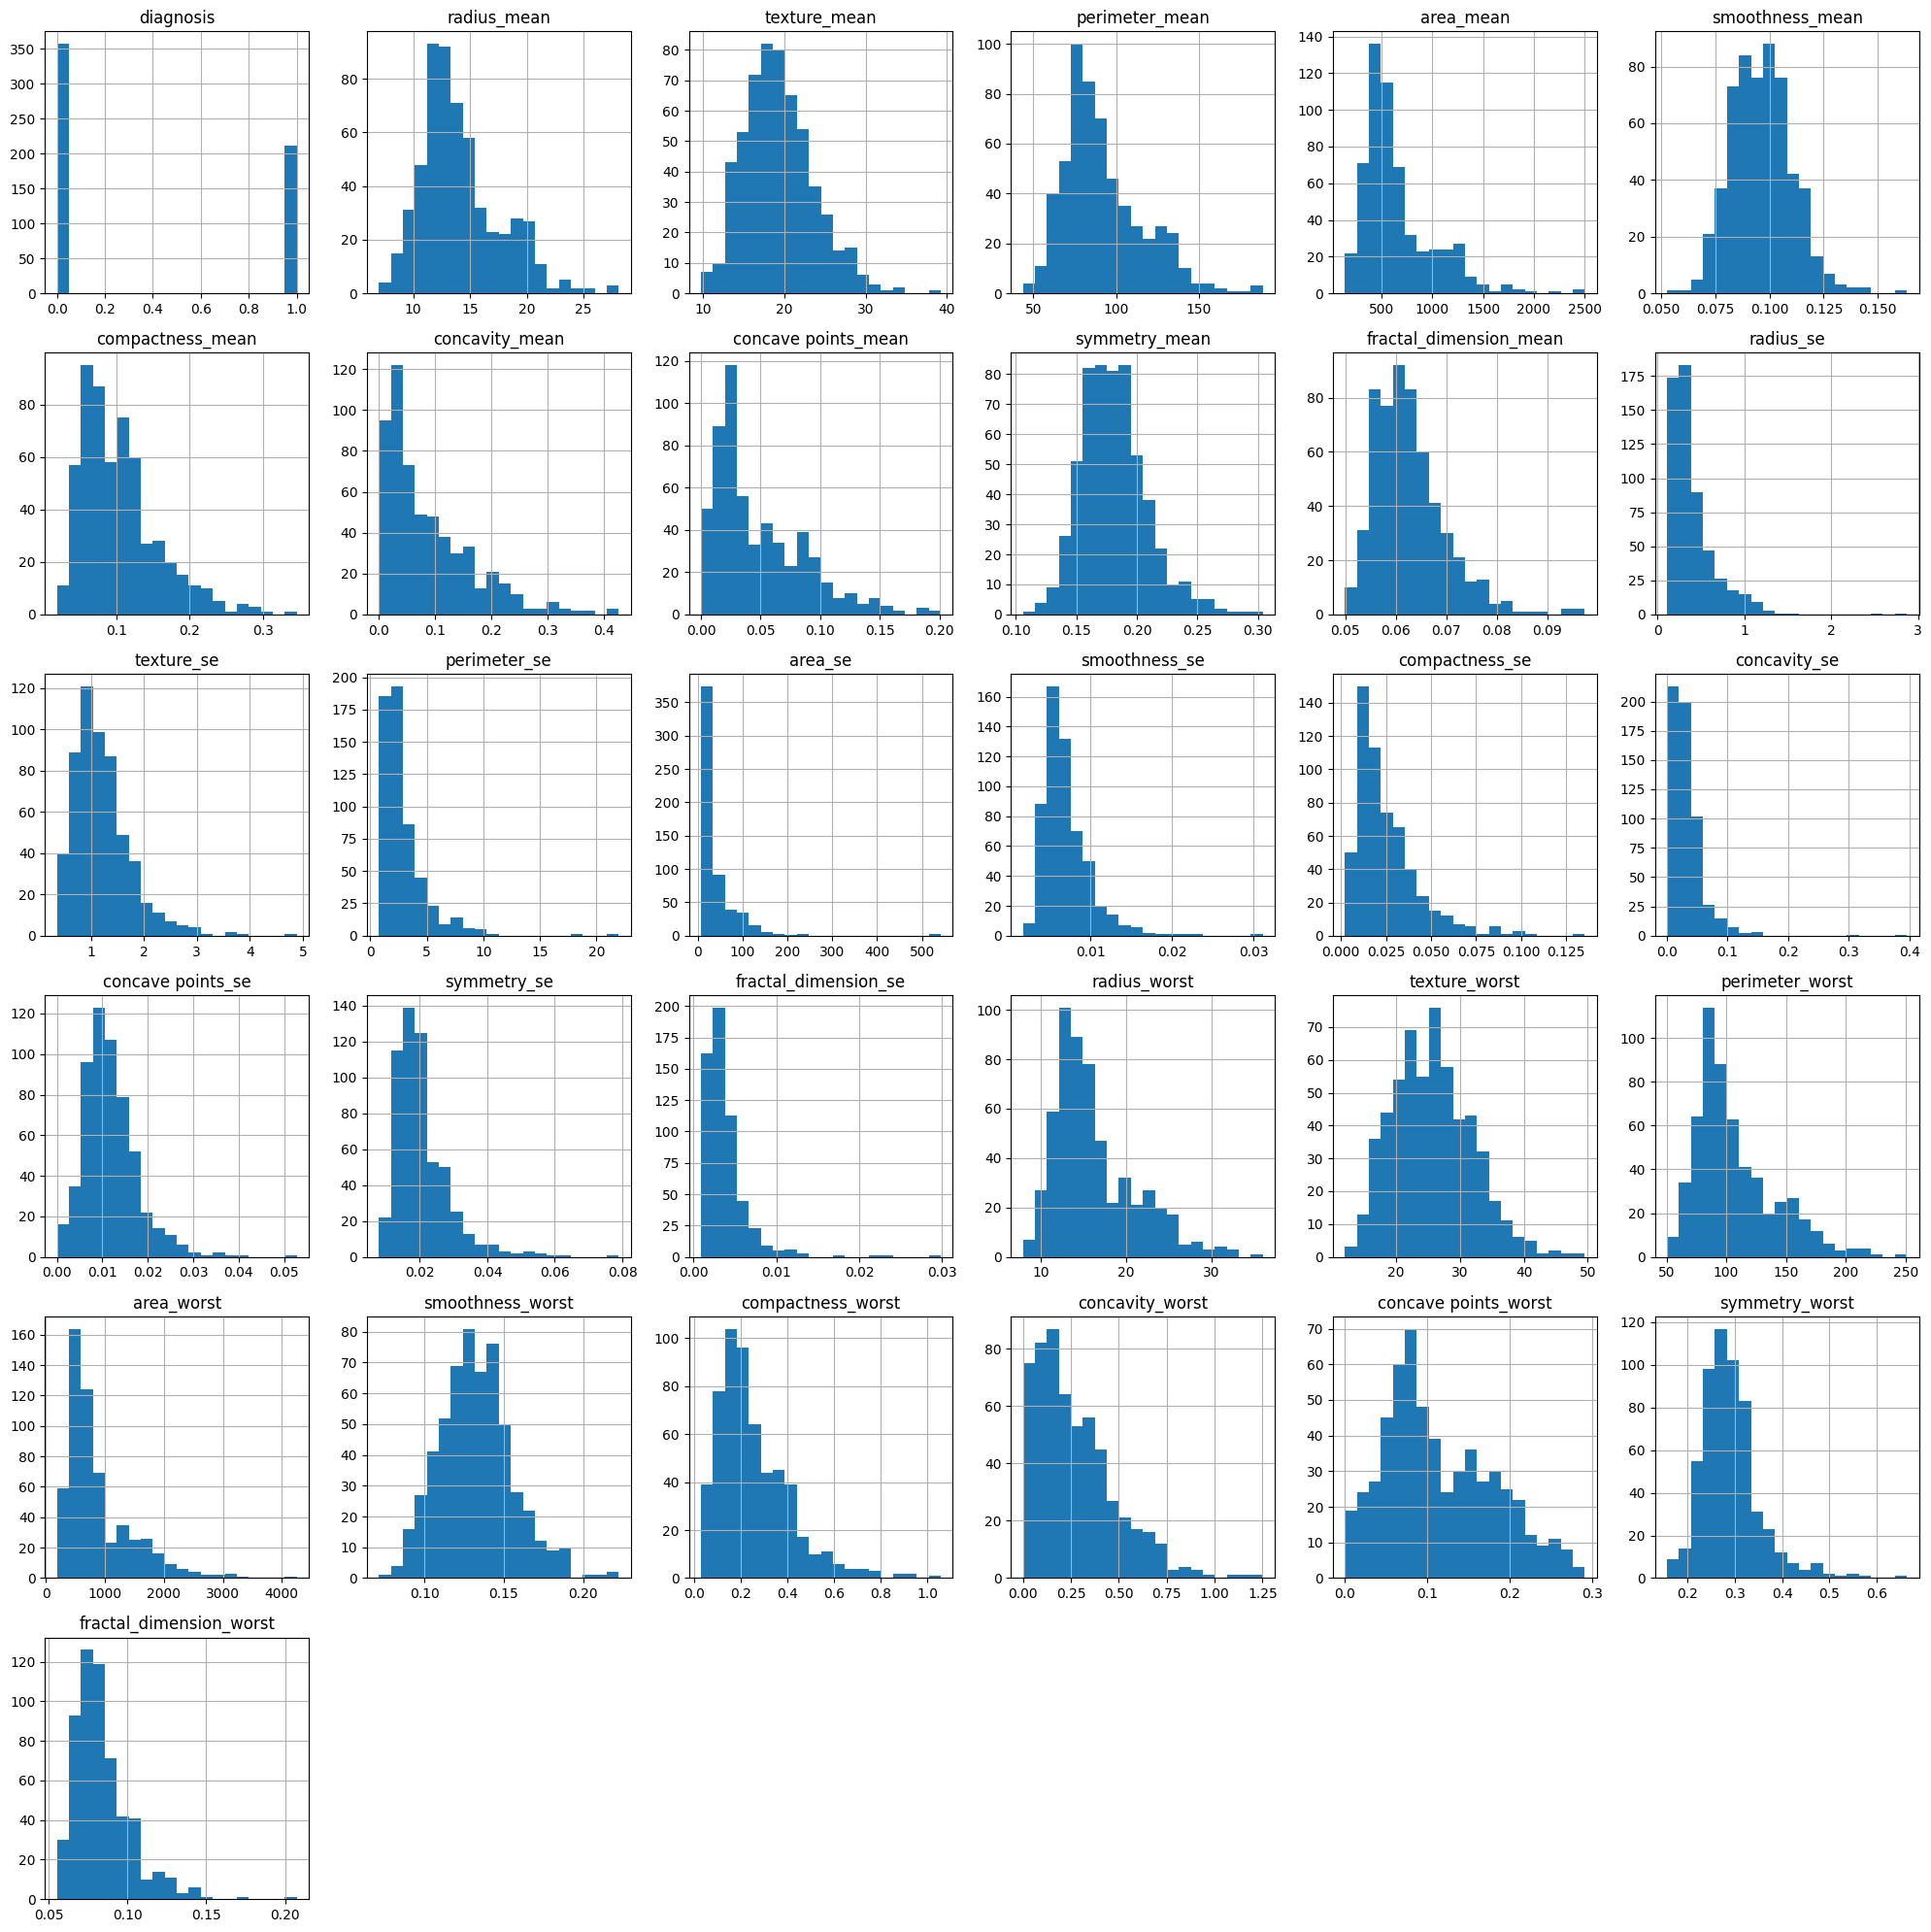

In [26]:
df.hist(figsize = (20,20), bins = 20)

plt.tight_layout()

Most of the numerical features exhibit a right-skewed (positively skewed) distribution. This indicates that the majority of observations are concentrated at lower values, while a smaller number of observations have relatively high values, creating a long tail on the right side. Some features also appear approximately normally distributed, while a few show potential extreme values that may represent outliers. These observations will be further examined using boxplots.

<function matplotlib.pyplot.show(close=None, block=None)>

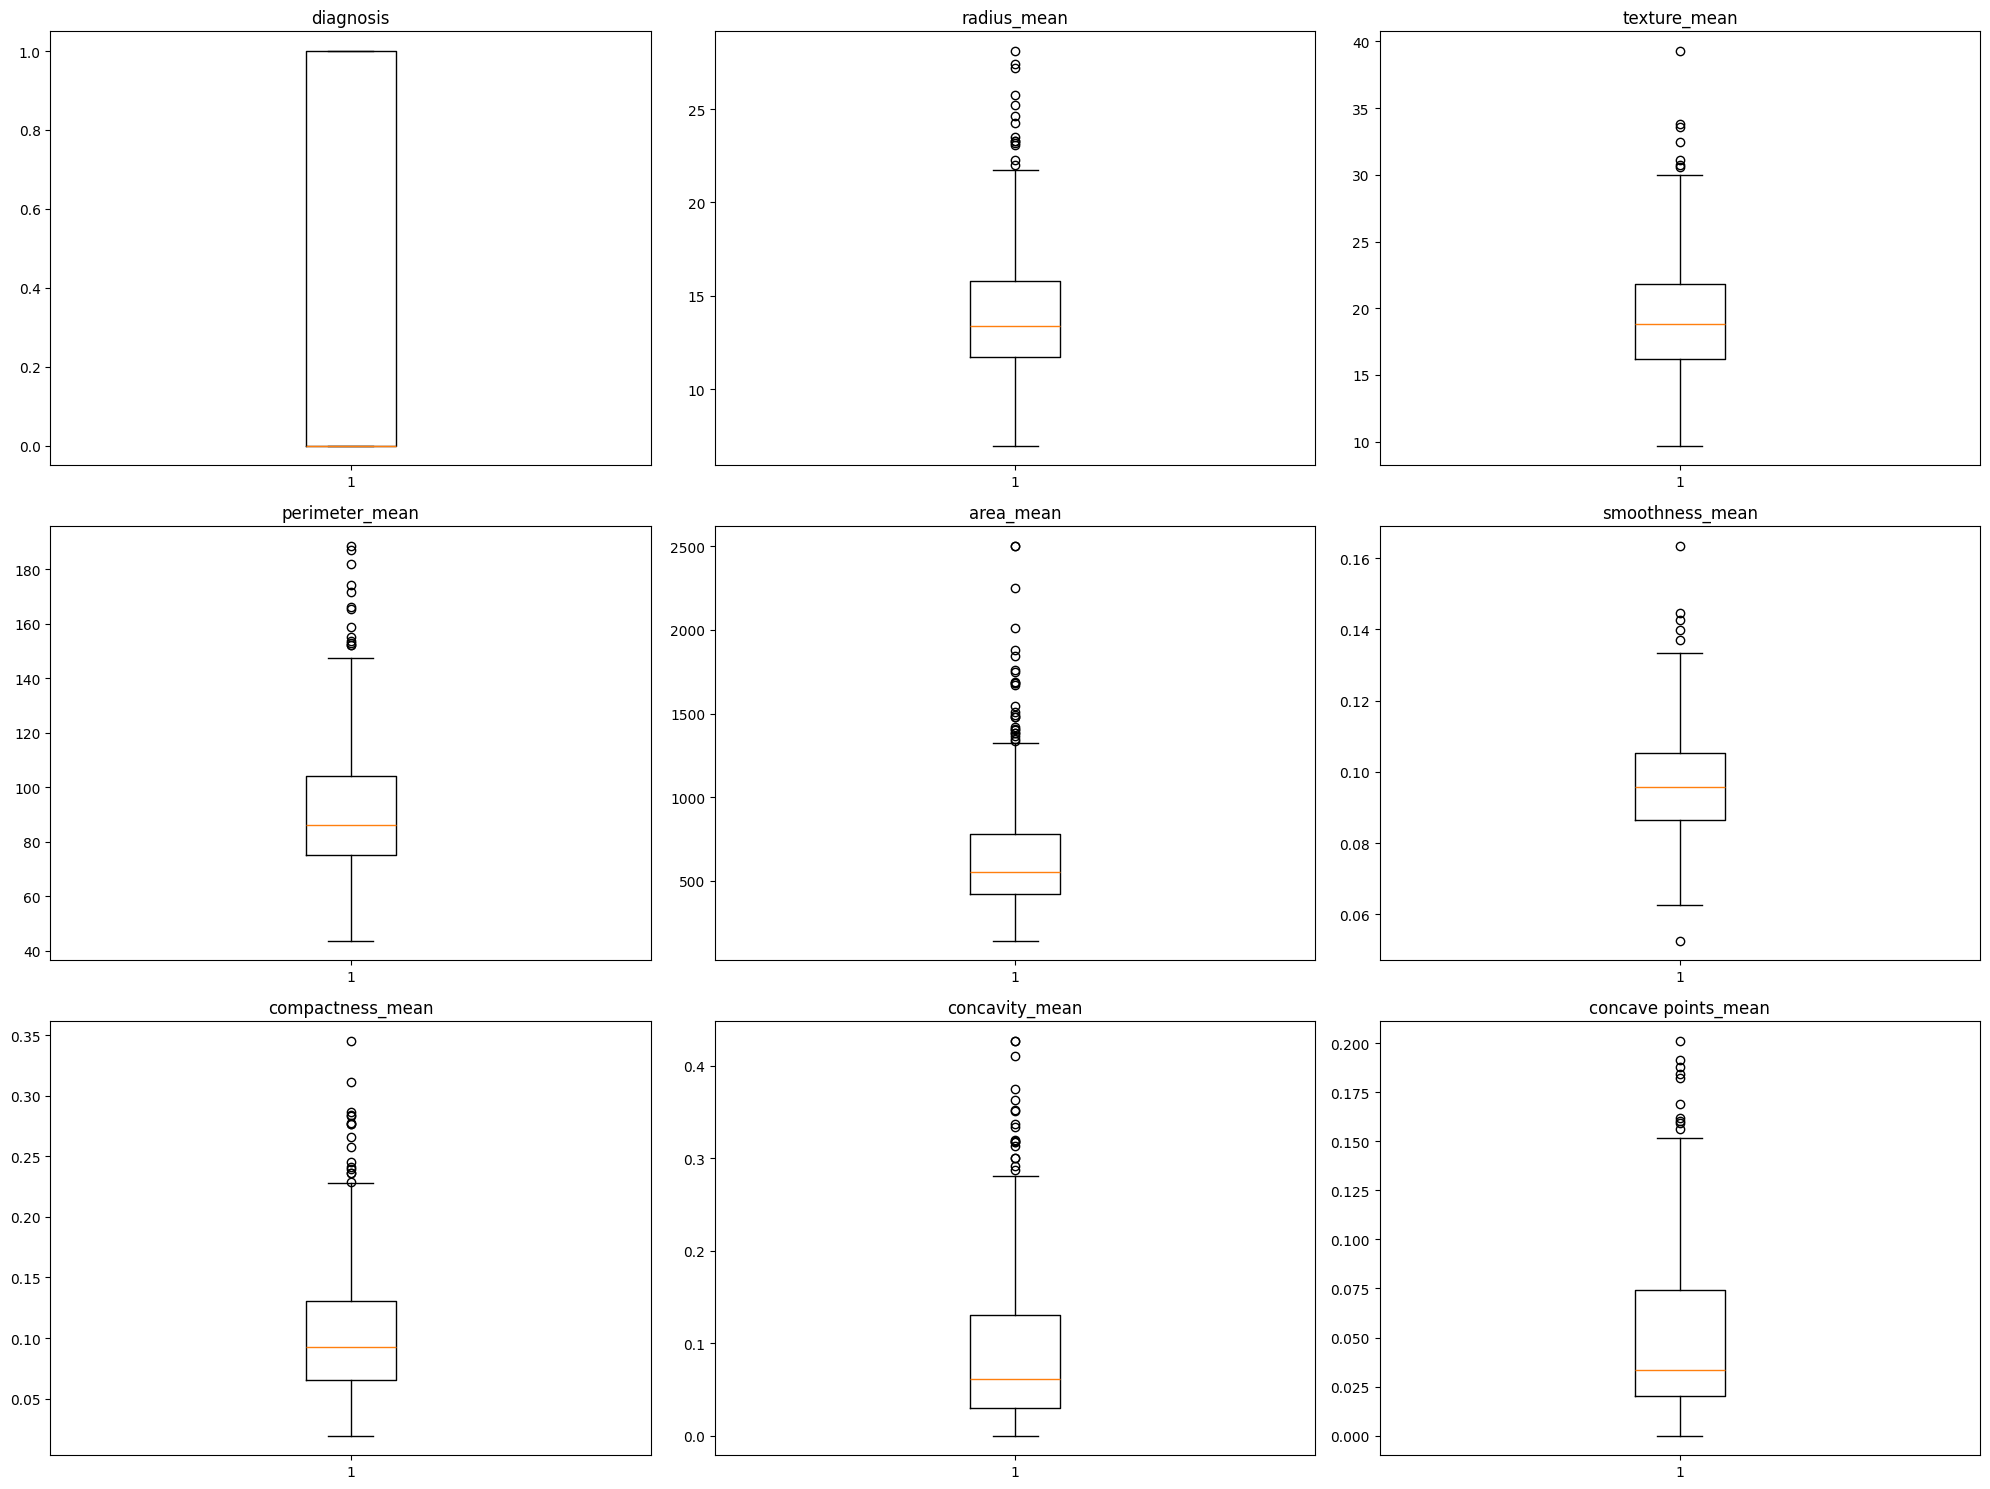

In [32]:
fig, axes = plt.subplots(3,3, figsize = (20,15))

for ax, col in zip(axes.flatten(), df.columns):
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show
    
    

The boxplots show that several numerical features contain outliers. Since this is a medical dataset, these outliers are likely to represent genuine patient measurements rather than errors. Therefore, the outliers will be retained and no outlier treatment will be performed.

In [34]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


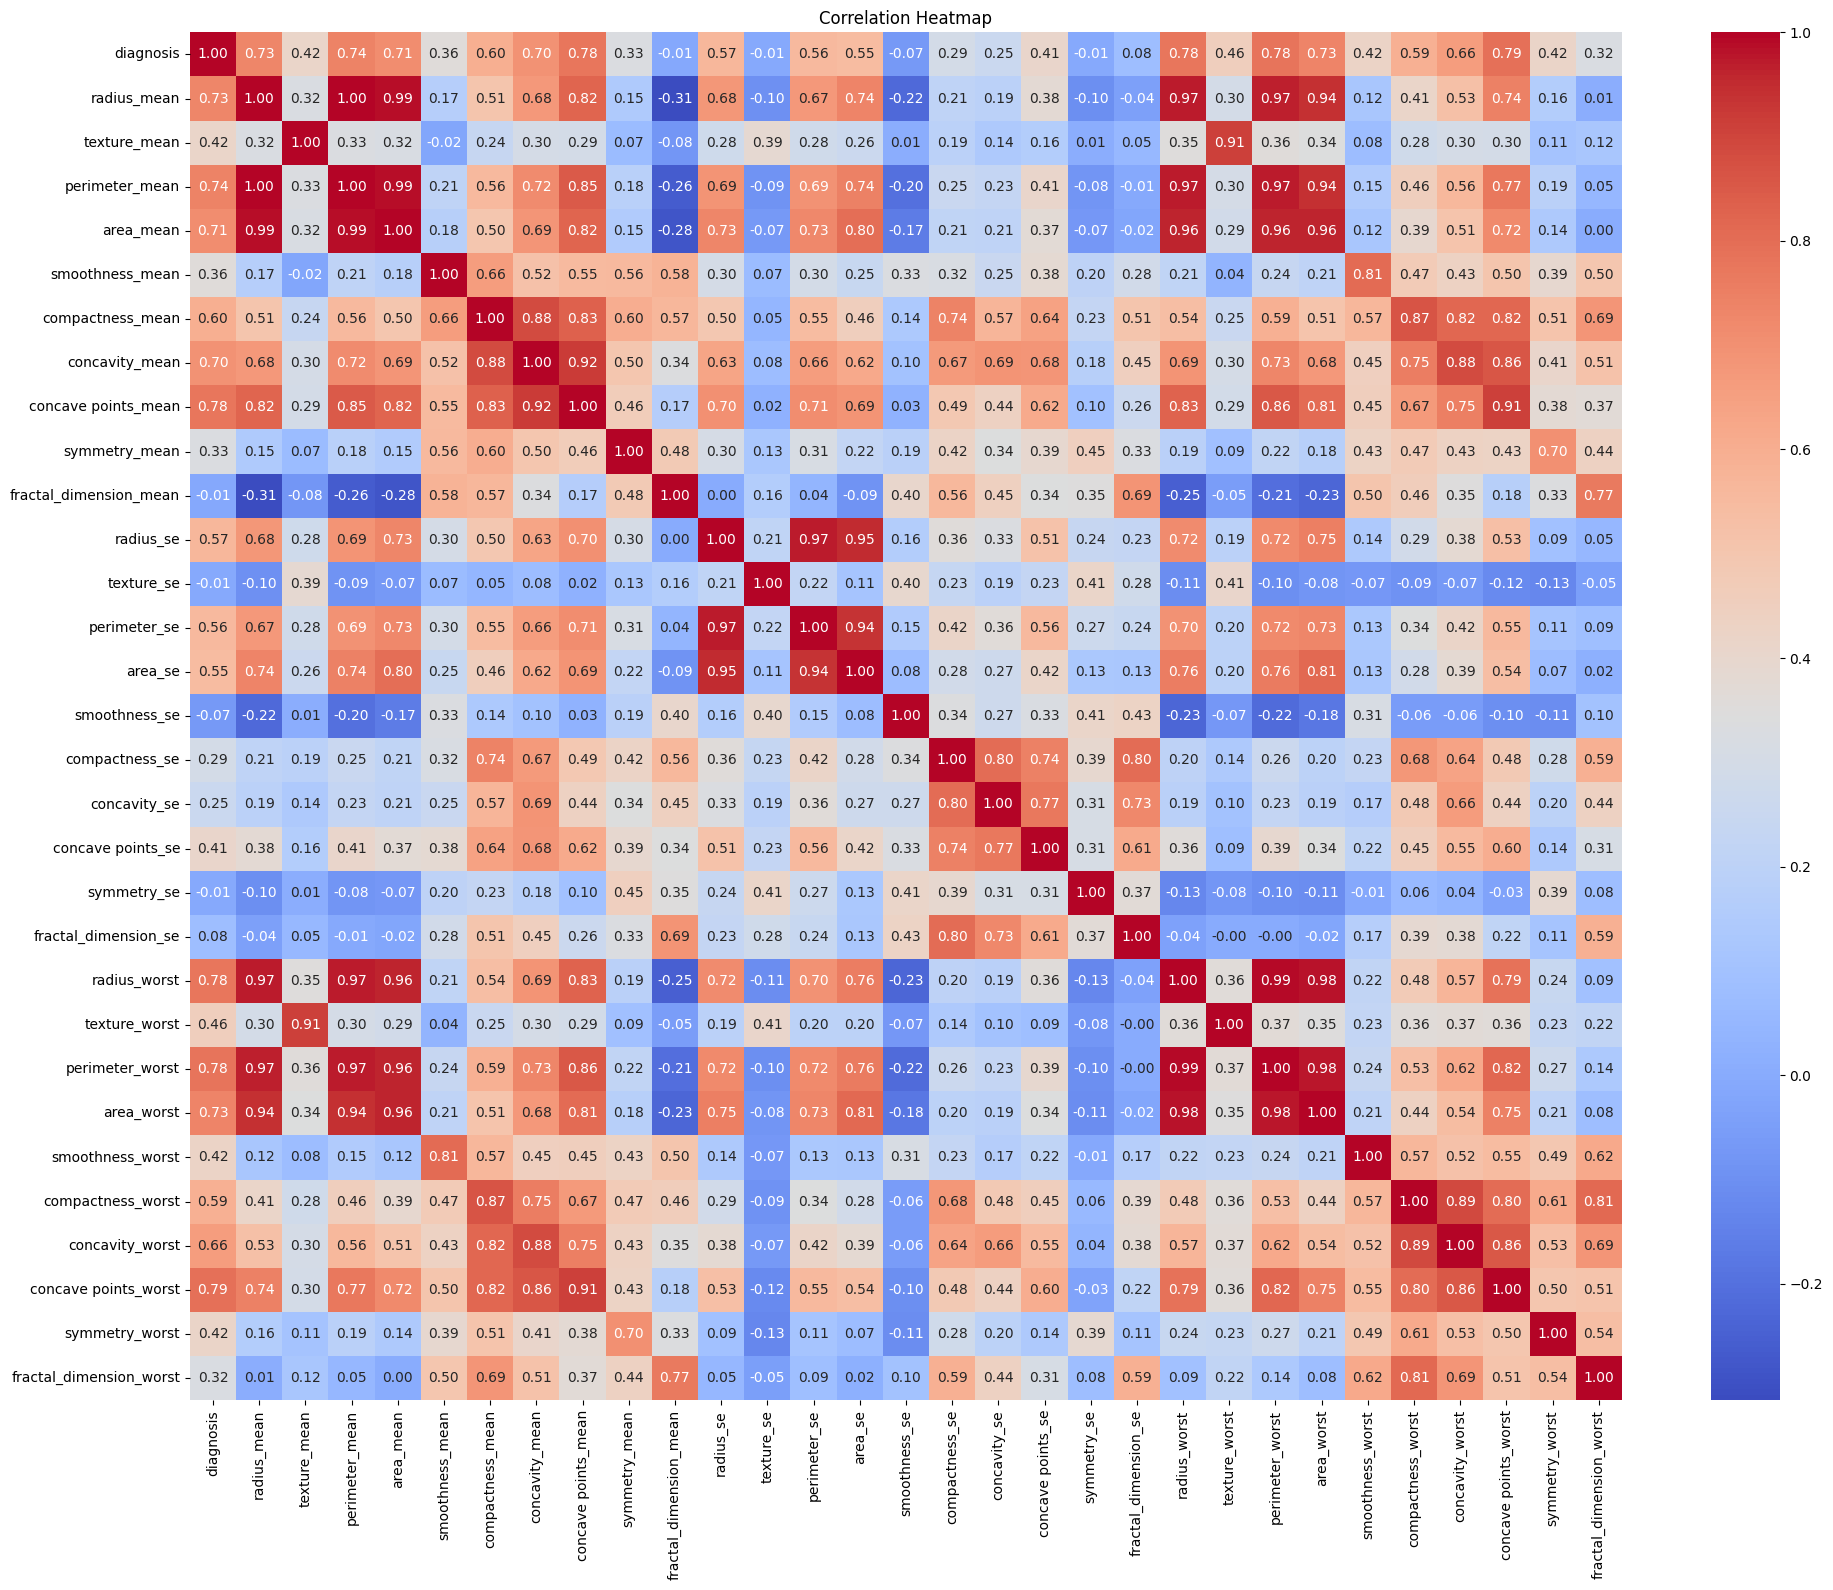

In [37]:
plt.figure(figsize = (20,16))

sns.heatmap( df.corr(), cmap = 'coolwarm', annot = True, fmt = '.2f')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation heatmap shows that several features are highly positively correlated, particularly those related to tumor size, such as radius, perimeter, and area. This is expected because these measurements describe similar characteristics of the tumor. Since Support Vector Machine (SVM) is generally less sensitive to multicollinearity, these features will be retained for model training.

In [38]:
# Separate Features and Target

x = df.drop('diagnosis', axis = 1)
y = df['diagnosis']

In [41]:
# Train test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20, stratify = y, random_state = 42)

In [44]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Training the SVM Model using a Linear Kernel

The first model is trained using a Linear kernel to establish a baseline performance.

A Linear SVM attempts to separate the classes using a straight-line decision boundary (or a hyperplane in higher dimensions). If the data is approximately linearly separable, the Linear kernel may achieve good performance. Otherwise, more flexible kernels such as RBF or Polynomial will be explored.

In [46]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')

svc.fit(x_train_scaled, y_train)

SVC(kernel='linear')

In [47]:
y_pred1 = svc.predict(x_test_scaled)

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred1))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred1))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))

Accuracy Score: 0.9649122807017544

Confusion Matrix:
[[72  0]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



The Linear SVM achieved an accuracy of 96%, indicating that it performs well on this dataset. However, SVM supports multiple kernel functions, each capable of capturing different types of decision boundaries. To perform a comprehensive comparison and identify the most suitable kernel for this classification problem, the RBF and Polynomial kernels will also be evaluated. This comparison helps determine whether a non-linear kernel offers any performance improvement over the linear model.

In [51]:
from sklearn.svm import SVC

rbf = SVC( kernel = 'rbf' )
rbf.fit(x_train_scaled, y_train)
y_pred2 = rbf.predict(x_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred2))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred2))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy Score: 0.9736842105263158

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



# Observation for RBF Kernel

The RBF kernel achieved an accuracy of 97.37%, outperforming the Linear kernel. It also achieved high precision, recall, and F1-score, while reducing the number of false negatives from 4 to 3. This indicates that the RBF kernel is able to capture the underlying patterns in the data more effectively, making it the best-performing kernel among those evaluated.

In [53]:
from sklearn.svm import SVC
poly = SVC(kernel = 'poly')
poly.fit(x_train_scaled, y_train)
y_pred3 = poly.predict(x_test_scaled)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred3))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred3))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred3))

Accuracy Score: 0.8859649122807017

Confusion Matrix:
[[72  0]
 [13 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        72
           1       1.00      0.69      0.82        42

    accuracy                           0.89       114
   macro avg       0.92      0.85      0.87       114
weighted avg       0.90      0.89      0.88       114



# Observation for Polynomial Kernel

The Polynomial kernel achieved an accuracy of 88.60%, which is lower than both the Linear and RBF kernels. It also produced a lower recall for the positive class, resulting in 13 false negatives. This suggests that the Polynomial kernel was not well suited for this dataset, as it failed to correctly identify a larger number of positive cases.

## Observation after comparing all kernels

 Among the three kernels evaluated, the RBF kernel achieved the best overall performance with an accuracy of 97.37%. It also produced the highest recall for the positive class and reduced the number of false negatives compared to the Linear and Polynomial kernels. In a breast cancer classification problem, minimizing false negatives is especially important because failing to identify a patient with cancer may delay diagnosis and treatment. Therefore, the RBF kernel was selected as the final model for further optimization using hyperparameter tuning

# Hyperparameter Tuning

The RBF kernel was selected based on its superior performance. However, the default hyperparameter values may not produce the best possible model.

Hyperparameter tuning is performed to identify the optimal combination of hyperparameters that maximizes the model's predictive performance and improves its ability to generalize to unseen data.

In this project, GridSearchCV is used to systematically evaluate different combinations of hyperparameters using cross-validation and select the best-performing model.

In [63]:
from sklearn.model_selection import GridSearchCV



# Define param grid

param_grid = {
    'C': [ 0.1, 1,10,100 ],
    'gamma': [ 1, 0.1, 0.01, 0.001 ],
    'kernel': ['rbf']
}

# Create the GridSearchCV object

grid_cv = GridSearchCV( rbf, param_grid = param_grid, cv=5, scoring = 'f1', n_jobs = -1 )

In [64]:
# Train the model

grid_cv.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='f1')

In [65]:
# View the Best Parameters

print('Best parameters :', grid_cv.best_params_)
print('Best Cross Validation Score:', grid_cv.best_score_)

Best parameters : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross Validation Score: 0.9667008847166881


In [66]:
Best_svm = grid_cv.best_estimator_

In [67]:
y_pred4 = Best_svm.predict(x_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score:", accuracy_score(y_test, y_pred4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred4))

Accuracy Score: 0.9824561403508771

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



ROC-AUC Score: 0.9761904761904762


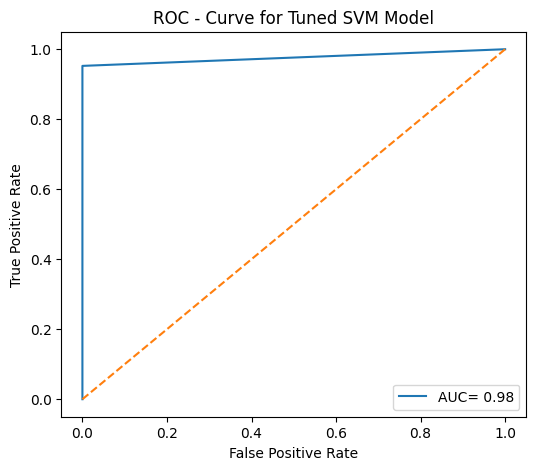

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred4)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred4)

print("ROC-AUC Score:", auc_score)

#Plot ROC_CURVE

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label = f"AUC= {auc_score:.2f}")
plt.plot( [0,1], [0,1], linestyle = '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Curve for Tuned SVM Model")
plt.legend(loc = "lower right")
plt.show()

# Observation

After hyperparameter tuning using GridSearchCV, the performance of the RBF SVM improved further. The tuned model achieved an accuracy of 98.25%, correctly classifying 112 out of 114 test samples. It also reduced the number of false negatives from 3 to 2, increasing the recall for the positive class from 0.93 to 0.95. These improvements indicate that tuning the hyperparameters helped the model generalize better and enhanced its ability to correctly identify positive cases.

# Prediction on unseen data

In [78]:
import pandas as pd

new_data = pd.DataFrame({
    'radius_mean': [14.2],
    'texture_mean': [20.5],
    'perimeter_mean': [92.3],
    'area_mean': [640.5],
    'smoothness_mean': [0.102],
    'compactness_mean': [0.125],
    'concavity_mean': [0.095],
    'concave points_mean': [0.052],
    'symmetry_mean': [0.185],
    'fractal_dimension_mean': [0.063],

    'radius_se': [0.45],
    'texture_se': [1.2],
    'perimeter_se': [3.1],
    'area_se': [40.5],
    'smoothness_se': [0.006],
    'compactness_se': [0.025],
    'concavity_se': [0.030],
    'concave points_se': [0.012],
    'symmetry_se': [0.020],
    'fractal_dimension_se': [0.004],

    'radius_worst': [16.8],
    'texture_worst': [28.5],
    'perimeter_worst': [110.2],
    'area_worst': [870.5],
    'smoothness_worst': [0.135],
    'compactness_worst': [0.250],
    'concavity_worst': [0.280],
    'concave points_worst': [0.120],
    'symmetry_worst': [0.290],
    'fractal_dimension_worst': [0.080]
})


In [85]:
# Scaling the features

new_data_scaled = scaler.transform(new_data)

In [86]:
new_data_pred = Best_svm.predict(new_data_scaled)

In [87]:
new_data_pred

array([0])

In [89]:
if new_data_pred[0] == 0:
    print("Prediction: N (Benign)")
else:
    print("Prediction: R (Malignant)")

Prediction: N (Benign)


# # Model Performance Comparison

In [90]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear SVM', 'RBF SVM', 'Polynomial SVM', 'Tuned RBF SVM'],
    'Accuracy': [96.49, 97.37, 88.60, 98.25],
    'Precision': [1.00, 1.00, 1.00, 1.00],
    'Recall': [0.90, 0.93, 0.69, 0.95],
    'F1-Score': [0.95, 0.96, 0.82, 0.98],
    'False Negatives': [4, 3, 13, 2]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,False Negatives
0,Linear SVM,96.49,1.0,0.90,0.95,4
1,RBF SVM,97.37,1.0,0.93,0.96,3
2,Polynomial SVM,88.60,1.0,0.69,0.82,13
3,Tuned RBF SVM,98.25,1.0,0.95,0.98,2


# Conclusion

In this project, a Support Vector Machine (SVM) was built to classify breast cancer cases as benign or malignant. The dataset was first preprocessed by handling the target encoding, performing exploratory data analysis, and scaling the features using StandardScaler, as SVM is sensitive to feature magnitudes.

To identify the most suitable model, Linear, RBF, and Polynomial kernels were evaluated. Although the Linear kernel achieved a strong accuracy of 96.49%, the RBF kernel was further explored because it is capable of capturing more complex decision boundaries. The RBF kernel improved the accuracy to 97.37% while also reducing the number of false negatives, an important factor in medical diagnosis where missing a cancer case can have serious consequences.

To further optimize the model, GridSearchCV was used to tune the hyperparameters C and gamma. The tuned RBF SVM achieved a final accuracy of 98.25% with a ROC-AUC score of 0.976, demonstrating excellent classification performance. Based on these results, the tuned RBF SVM was selected as the final model because it provided the best balance between overall accuracy and reliable identification of positive cases.